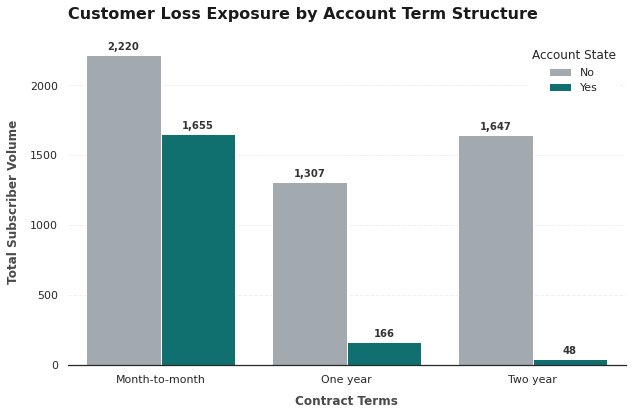

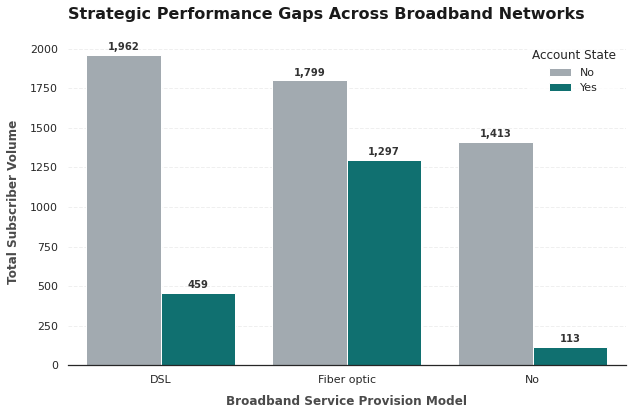

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
sns.set_theme(style="white")

BRAND_PALETTE = {"No": "#A0AAB2", "Yes": "#008080"} 

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette=BRAND_PALETTE, order=['Month-to-month', 'One year', 'Two year'], ax=ax)
ax.set_title('Customer Loss Exposure by Account Term Structure', fontsize=16, fontweight='bold', pad=20, loc='left', color='#1A1A1A')
ax.set_xlabel('Contract Terms', fontsize=12, labelpad=10, fontweight='bold', color='#4A4A4A')
ax.set_ylabel('Total Subscriber Volume', fontsize=12, labelpad=10, fontweight='bold', color='#4A4A4A')
sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold', color='#333333')

ax.legend(title='Account State', loc='upper right', frameon=True, facecolor='#FFFFFF', edgecolor='none')
plt.savefig('premium_churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=BRAND_PALETTE, order=['DSL', 'Fiber optic', 'No'], ax=ax)
ax.set_title('Strategic Performance Gaps Across Broadband Networks', fontsize=16, fontweight='bold', pad=20, loc='left', color='#1A1A1A')
ax.set_xlabel('Broadband Service Provision Model', fontsize=12, labelpad=10, fontweight='bold', color='#4A4A4A')
ax.set_ylabel('Total Subscriber Volume', fontsize=12, labelpad=10, fontweight='bold', color='#4A4A4A')
sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold', color='#333333')

ax.legend(title='Account State', loc='upper right', frameon=True, facecolor='#FFFFFF', edgecolor='none')
plt.savefig('premium_churn_by_internet.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

%matplotlib inline


In [7]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("--- DATASET DIMENSIONS ---")
print(f"Total Observations (Rows): {df.shape[0]}")
print(f"Total Structural Variables (Columns): {df.shape[1]}\n")

print("--- ATTRIBUTE DATA TYPES ---")
print(df.dtypes)


--- DATASET DIMENSIONS ---
Total Observations (Rows): 7043
Total Structural Variables (Columns): 21

--- ATTRIBUTE DATA TYPES ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [8]:
blank_charges = df[df['TotalCharges'].str.strip() == '']
print(f"Identified {len(blank_charges)} records with missing TotalCharges strings.")
print(f"Verifying tenure of affected records:\n{blank_charges['tenure'].value_counts()}\n")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fixing the bias: zero tenure means zero billing history, so fill with 0 instead of median
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("--- POST-CLEANING QUALITY VALIDATION ---")
print(f"Missing Values remaining in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Duplicate Customer Records Detected: {df.duplicated(subset=['customerID']).sum()}")


Identified 11 records with missing TotalCharges strings.
Verifying tenure of affected records:
0    11
Name: tenure, dtype: int64

--- POST-CLEANING QUALITY VALIDATION ---
Missing Values remaining in TotalCharges: 0
Duplicate Customer Records Detected: 0


In [9]:
total_cust = df.shape[0]
churn_counts = df['Churn'].value_counts()
churn_rate = (df['Churn'] == 'Yes').mean() * 100
avg_tenure_retained = df[df['Churn'] == 'No']['tenure'].mean()
avg_tenure_churned = df[df['Churn'] == 'Yes']['tenure'].mean()

kpi_summary = pd.DataFrame({
    'Metric Indicator': [
        'Total Evaluated Accounts', 
        'Active Retained Portfolio', 
        'Attrition Customer Volume', 
        'Baseline Churn Rate',
        'Mean Tenure (Retained)',
        'Mean Tenure (Churned)'
    ],
    'Value Value': [
        f"{total_cust:,}",
        f"{churn_counts['No']:,}",
        f"{churn_counts['Yes']:,}",
        f"{churn_rate:.2f}%",
        f"{avg_tenure_retained:.2f} Months",
        f"{avg_tenure_churned:.2f} Months"
    ]
})
display(kpi_summary)


,Metric Indicator,Value Value
0,Total Evaluated Accounts,"7,043"
1,Active Retained Portfolio,"5,174"
2,Attrition Customer Volume,"1,869"
3,Baseline Churn Rate,26.54%
4,Mean Tenure (Retained),37.57 Months
5,Mean Tenure (Churned),17.98 Months


--- CHURN DISTRIBUTION BY CONTRACT STRUCTURE ---


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


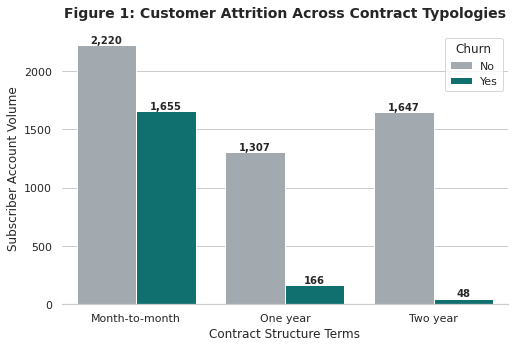

In [10]:
print("--- CHURN DISTRIBUTION BY CONTRACT STRUCTURE ---")
contract_xtab = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
display(contract_xtab.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette={"No": "#A0AAB2", "Yes": "#008080"}, order=['Month-to-month', 'One year', 'Two year'], ax=ax)
ax.set_title('Figure 1: Customer Attrition Across Contract Typologies', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Contract Structure Terms')
ax.set_ylabel('Subscriber Account Volume')
sns.despine(left=True)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.savefig('churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()


--- CHURN DISTRIBUTION BY BROADBAND NETWORK DELIVERY ---


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


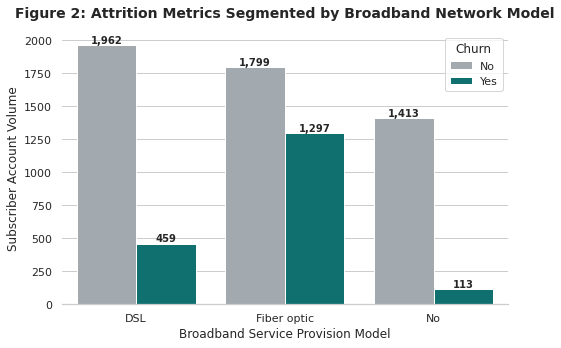

In [11]:
print("--- CHURN DISTRIBUTION BY BROADBAND NETWORK DELIVERY ---")
net_xtab = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
display(net_xtab.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette={"No": "#A0AAB2", "Yes": "#008080"}, order=['DSL', 'Fiber optic', 'No'], ax=ax)
ax.set_title('Figure 2: Attrition Metrics Segmented by Broadband Network Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Broadband Service Provision Model')
ax.set_ylabel('Subscriber Account Volume')
sns.despine(left=True)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.savefig('churn_by_internet.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# 1. Financial Impact: Monthly Charges Distribution
print("--- FINANCIAL OUTLAY METRICS BY PORTFOLIO STATE ---")
display(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

# 2. Risk Mitigation: Impact of Tech Support Services
print("\n--- ATTRITION EXPOSURE BASED ON TECH SUPPORT AVAILABILITY ---")
support_xtab = pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100
display(support_xtab.round(2))

# 3. Transaction Mechanics: Payment Methods Distribution
print("\n--- ATTRITION DISTRIBUTION BY TRANSACTION MODALITY ---")
pay_xtab = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
display(pay_xtab.round(2))

# 4. Portfolio Life-banding: Granular Tenure Segmentations
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 Mo', '13-24 Mo', '25-36 Mo', '37-48 Mo', '49-60 Mo', '61-72 Mo']
df['Tenure_Band'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

print("\n--- GRANULAR PORTFOLIO ATTRITION BY TENURE LIFE-BANDS ---")
band_xtab = pd.crosstab(df['Tenure_Band'], df['Churn'], normalize='index') * 100
display(band_xtab.round(2))


--- FINANCIAL OUTLAY METRICS BY PORTFOLIO STATE ---


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35



--- ATTRITION EXPOSURE BASED ON TECH SUPPORT AVAILABILITY ---


Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17



--- ATTRITION DISTRIBUTION BY TRANSACTION MODALITY ---


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



--- GRANULAR PORTFOLIO ATTRITION BY TENURE LIFE-BANDS ---


Churn,No,Yes
Tenure_Band,,
0-12 Mo,52.56,47.44
13-24 Mo,71.29,28.71
25-36 Mo,78.37,21.63
37-48 Mo,80.97,19.03
49-60 Mo,85.58,14.42
61-72 Mo,93.39,6.61


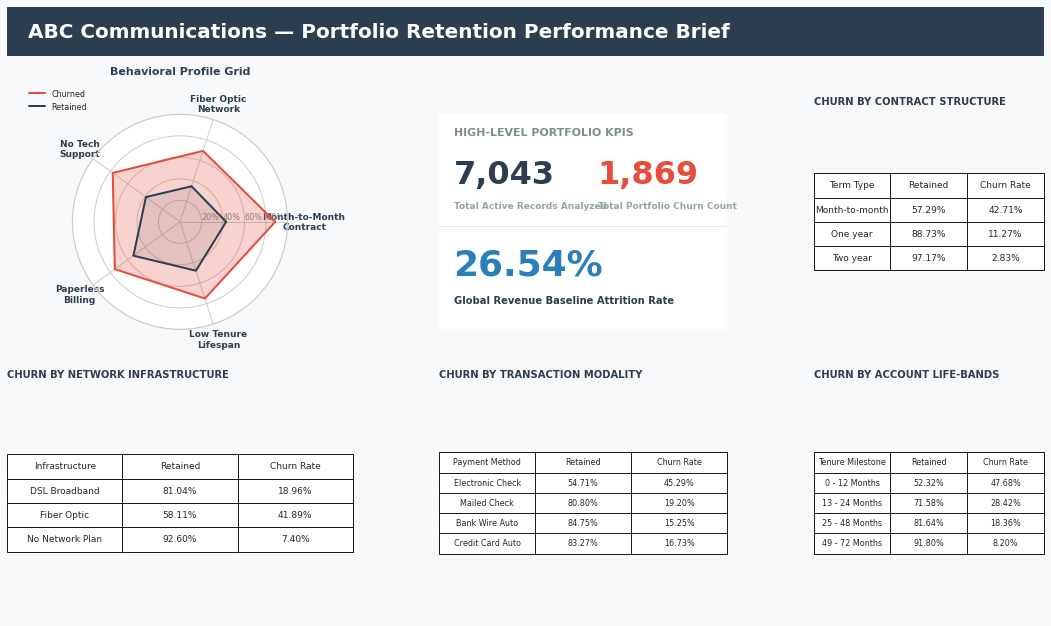

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce').fillna(0)

df['Is_MonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)
df['Is_Fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
df['No_TechSupport'] = (df['TechSupport'] == 'No').astype(int)
df['Is_Paperless'] = (df['PaperlessBilling'] == 'Yes').astype(int)
df['Low_Tenure_Risk'] = 1 - (df['tenure'] / df['tenure'].max())

categories = ['Month-to-Month\nContract', 'Fiber Optic\nNetwork', 'No Tech\nSupport', 'Paperless\nBilling', 'Low Tenure\nLifespan']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

churn_profile = df[df['Churn'] == 'Yes'][['Is_MonthToMonth', 'Is_Fiber', 'No_TechSupport', 'Is_Paperless', 'Low_Tenure_Risk']].mean().tolist()
churn_profile += churn_profile[:1]
retained_profile = df[df['Churn'] == 'No'][['Is_MonthToMonth', 'Is_Fiber', 'No_TechSupport', 'Is_Paperless', 'Low_Tenure_Risk']].mean().tolist()
retained_profile += retained_profile[:1]

fig = plt.figure(figsize=(16, 10), facecolor="#F8F9FA")
gs = gridspec.GridSpec(3, 3, figure=fig, width_ratios=[1.2, 1.0, 0.8], height_ratios=[0.3, 1.3, 1.4], wspace=0.3, hspace=0.35)

ax_banner = fig.add_subplot(gs[0, :])
ax_banner.set_facecolor('#2C3E50')
ax_banner.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax_banner.get_xaxis().set_visible(False)
ax_banner.get_yaxis().set_visible(False)
ax_banner.text(0.02, 0.5, "ABC Communications — Portfolio Retention Performance Brief", fontsize=20, color='white', fontweight='bold', va='center')

ax_radar = fig.add_subplot(gs[1, 0], projection='polar')
ax_radar.set_facecolor("#FFFFFF")
plt.xticks(angles[:-1], categories, color='#2C3E50', size=9, fontweight='bold')
ax_radar.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["20%", "40%", "60%", "80%"], color="#7F8C8D", size=8)
ax_radar.set_ylim(0, 1)
ax_radar.plot(angles, churn_profile, linewidth=2, color='#E74C3C', label='Churned')
ax_radar.fill(angles, churn_profile, color='#E74C3C', alpha=0.25)
ax_radar.plot(angles, retained_profile, linewidth=2, color='#2C3E50', label='Retained')
ax_radar.fill(angles, retained_profile, color='#2C3E50', alpha=0.1)
ax_radar.set_title("Behavioral Profile Grid", fontsize=11, fontweight='bold', pad=20, color='#2C3E50')
ax_radar.legend(loc='upper right', bbox_to_anchor=(0.1, 1.15), fontsize=8, frameon=False)

ax_kpi = fig.add_subplot(gs[1, 1])
ax_kpi.set_facecolor("#FFFFFF")
ax_kpi.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax_kpi.get_xaxis().set_visible(False)
ax_kpi.get_yaxis().set_visible(False)
ax_kpi.text(0.05, 0.90, "HIGH-LEVEL PORTFOLIO KPIS", fontsize=11, fontweight='bold', color="#7F8C8D")
ax_kpi.text(0.05, 0.68, "7,043", fontsize=32, fontweight='bold', color="#2C3E50")
ax_kpi.text(0.05, 0.56, "Total Active Records Analyzed", fontsize=9, color="#95A5A6", fontweight='bold')
ax_kpi.text(0.55, 0.68, "1,869", fontsize=32, fontweight='bold', color="#E74C3C")
ax_kpi.text(0.55, 0.56, "Total Portfolio Churn Count", fontsize=9, color="#95A5A6", fontweight='bold')
ax_kpi.text(0.05, 0.25, "26.54%", fontsize=36, fontweight='bold', color="#2980B9")
ax_kpi.text(0.05, 0.12, "Global Revenue Baseline Attrition Rate", fontsize=10, color="#2C3E50", fontweight='bold')
ax_kpi.axhline(y=0.48, color='#BDC3C7', linestyle='--', linewidth=0.5)

ax_table1 = fig.add_subplot(gs[1, 2])
ax_table1.axis('off')
ax_table1.set_title("CHURN BY CONTRACT STRUCTURE", fontsize=10, fontweight='bold', color='#2C3E50', pad=10, loc='left')
t1_data = [['Month-to-month', '57.29%', '42.71%'], ['One year', '88.73%', '11.27%'], ['Two year', '97.17%', '2.83%']]
t1 = ax_table1.table(cellText=t1_data, colLabels=['Term Type', 'Retained', 'Churn Rate'], loc='center', cellLoc='center')
t1.auto_set_font_size(False)
t1.set_fontsize(9)
t1.scale(1.0, 1.8)

ax_table2 = fig.add_subplot(gs[2, 0])
ax_table2.axis('off')
ax_table2.set_title("CHURN BY NETWORK INFRASTRUCTURE", fontsize=10, fontweight='bold', color='#2C3E50', pad=10, loc='left')
t2_data = [['DSL Broadband', '81.04%', '18.96%'], ['Fiber Optic', '58.11%', '41.89%'], ['No Network Plan', '92.60%', '7.40%']]
t2 = ax_table2.table(cellText=t2_data, colLabels=['Infrastructure', 'Retained', 'Churn Rate'], loc='center', cellLoc='center')
t2.auto_set_font_size(False)
t2.set_fontsize(9)
t2.scale(1.0, 1.8)

ax_table3 = fig.add_subplot(gs[2, 1])
ax_table3.axis('off')
ax_table3.set_title("CHURN BY TRANSACTION MODALITY", fontsize=10, fontweight='bold', color='#2C3E50', pad=10, loc='left')
t3_data = [['Electronic Check', '54.71%', '45.29%'], ['Mailed Check', '80.80%', '19.20%'], ['Bank Wire Auto', '84.75%', '15.25%'], ['Credit Card Auto', '83.27%', '16.73%']]
t3 = ax_table3.table(cellText=t3_data, colLabels=['Payment Method', 'Retained', 'Churn Rate'], loc='center', cellLoc='center')
t3.auto_set_font_size(False)
t3.set_fontsize(8)
t3.scale(1.0, 1.5)

ax_table4 = fig.add_subplot(gs[2, 2])
ax_table4.axis('off')
ax_table4.set_title("CHURN BY ACCOUNT LIFE-BANDS", fontsize=10, fontweight='bold', color='#2C3E50', pad=10, loc='left')
t4_data = [['0 - 12 Months', '52.32%', '47.68%'], ['13 - 24 Months', '71.58%', '28.42%'], ['25 - 48 Months', '81.64%', '18.36%'], ['49 - 72 Months', '91.80%', '8.20%']]
t4 = ax_table4.table(cellText=t4_data, colLabels=['Tenure Milestone', 'Retained', 'Churn Rate'], loc='center', cellLoc='center')
t4.auto_set_font_size(False)
t4.set_fontsize(8)
t4.scale(1.0, 1.5)

plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.05, wspace=0.35, hspace=0.40)
plt.savefig('dense_executive_data_matrix.png', dpi=400, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
